<a href="https://colab.research.google.com/github/varun1219c/IRIS_data_training/blob/main/iris_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [2]:
import torch.nn as nn

In [3]:
import torch.nn.functional as f

In [107]:
class Model(nn.Module):
  def __init__(self,in_features=4,h1=8,h2=8,out_features=3):
    super().__init__()
    self.fc1=nn.Linear(in_features,h1)
    self.fc2=nn.Linear(h1,h2)
    self.out=nn.Linear(h2,out_features)
  def forward(self,x):
    x=f.relu(self.fc1(x))
    x=f.relu(self.fc2(x))
    x=self.out(x)
    return x

In [ ]:
torch.manual_seed(41)
model=Model()

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
url='https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
df=pd.read_csv(url)

In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
df['species']=df['species'].replace('setosa',0.0)
df['species']=df['species'].replace('versicolor',1.0)
df['species']=df['species'].replace('virginica',2.0)
df

/tmp/ipykernel_1204/3680681121.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['species']=df['species'].replace('virginica',2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [ ]:
x=df.drop('species',axis=1)
y=df['species']

In [ ]:
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y

,species
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
145,2.0
146,2.0
147,2.0
148,2.0


In [ ]:
x=x.values
y=y.values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=41)

In [ ]:
xtrain=torch.FloatTensor(xtrain)
xtest=torch.FloatTensor(xtest)
ytrain=torch.LongTensor(ytrain)
ytest=torch.LongTensor(ytest)

In [ ]:
c=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [ ]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)>

In [ ]:
epochs=100
losses=[]
for i in range(epochs):
  y_pred=model.forward(xtrain)
  loss= c(y_pred,ytrain)
  losses.append(loss.detach().numpy())
  if i%10==0:
    print(f'Epoch: {i} and loss:{loss}')
  #backprop
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch: 0 and loss:1.1318050622940063
Epoch: 10 and loss:0.9658581614494324
Epoch: 20 and loss:0.67915278673172
Epoch: 30 and loss:0.40087202191352844
Epoch: 40 and loss:0.22570066154003143
Epoch: 50 and loss:0.12255845218896866
Epoch: 60 and loss:0.07509137690067291
Epoch: 70 and loss:0.05467577651143074
Epoch: 80 and loss:0.04448390752077103
Epoch: 90 and loss:0.038461681455373764


Text(0, 0.5, 'Epoch')

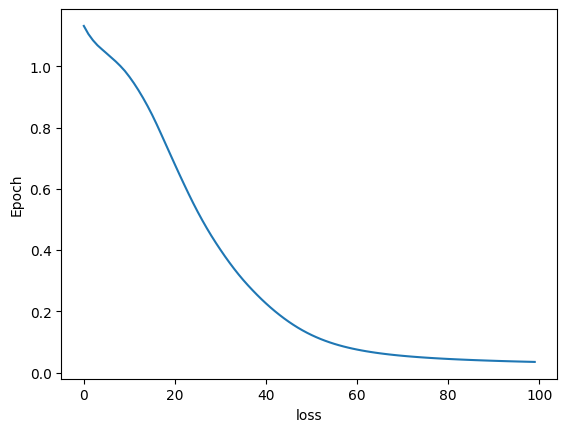

In [103]:
plt.plot(range(epochs),losses)
plt.xlabel("loss")
plt.ylabel("Epoch")

In [110]:
with torch.no_grad():
  y_eval=model.forward(xtest)
  loss=c(y_eval,ytest)
loss

tensor(0.1458)

In [118]:
correct=0
with torch.no_grad():
  for i,data in enumerate(xtest):
    y_val=model.forward(data)
    print(f'{i+1}.) {str(y_val)} \t{ytest[i]} \t {y_val.argmax().item()}')
    if y_val.argmax().item()==ytest[i]:
      correct+=1
print(f'We got {correct} correct!')

1.) tensor([-7.7132,  1.5807,  4.8588]) 	2 	 2
2.) tensor([-10.2249,   0.5155,   8.7638]) 	2 	 2
3.) tensor([-10.7185,   1.1882,   8.2269]) 	2 	 2
4.) tensor([-4.4690,  3.5339, -1.1210]) 	1 	 1
5.) tensor([-9.0873,  1.4669,  6.2793]) 	2 	 2
6.) tensor([-2.2770,  3.7022, -4.1140]) 	1 	 1
7.) tensor([-7.0673,  2.2028,  3.2917]) 	2 	 2
8.) tensor([-4.2226,  3.6468, -1.5420]) 	1 	 1
9.) tensor([-8.0634,  1.8251,  4.7820]) 	2 	 2
10.) tensor([-10.8515,   0.5058,   9.3629]) 	2 	 2
11.) tensor([-6.8611,  2.2126,  3.0811]) 	2 	 2
12.) tensor([  9.4301,   3.2669, -18.8494]) 	0 	 0
13.) tensor([  8.5966,   2.9338, -17.1305]) 	0 	 0
14.) tensor([-1.0571,  3.1664, -4.7063]) 	1 	 1
15.) tensor([  8.0257,   3.2468, -16.7651]) 	0 	 0
16.) tensor([-6.7032,  2.4148,  2.6586]) 	2 	 2
17.) tensor([  8.4607,   3.0915, -17.1118]) 	0 	 0
18.) tensor([-7.5983,  1.7014,  4.5610]) 	1 	 2
19.) tensor([  9.0443,   3.1470, -18.0944]) 	0 	 0
20.) tensor([  7.7209,   2.9005, -15.7171]) 	0 	 0
21.) tensor([-1.6889, 

In [119]:
new_iris=torch.tensor([3.2,4.2,2.3,0.1])

In [122]:
with torch.no_grad():
  print(model(new_iris))

tensor([  5.9373,   2.4531, -12.5328])


In [123]:
torch.save(model.state_dict(),'new_iris_model.pt')

In [125]:
new_model=Model()
new_model.load_state_dict(torch.load('new_iris_model.pt'))

<All keys matched successfully>

In [127]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)